# Task 6: House Price Prediction

## Objective
The objective of this project is to predict house prices using property features such as area, bedrooms, bathrooms, and location.

## Dataset
House Price Prediction Dataset

## Model
Linear Regression

# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# **Upload Dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


# **Load Dataset**

In [5]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# **Check Missing Values**

In [6]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# **Convert Categorical Columns**

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# **Check Data Types**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


# **Features and Target**

In [9]:
X = df.drop('price', axis=1)

y = df['price']

# **Train-Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Train Linear Regression Model**

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# **Predictions**

In [12]:
y_pred = model.predict(X_test)

# **MAE**

In [13]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 979679.6912959901


# **RMSE**

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1331071.4167895108


# **R² Score**

In [15]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.6494754192267803


# **Actual vs Predicted Graph**

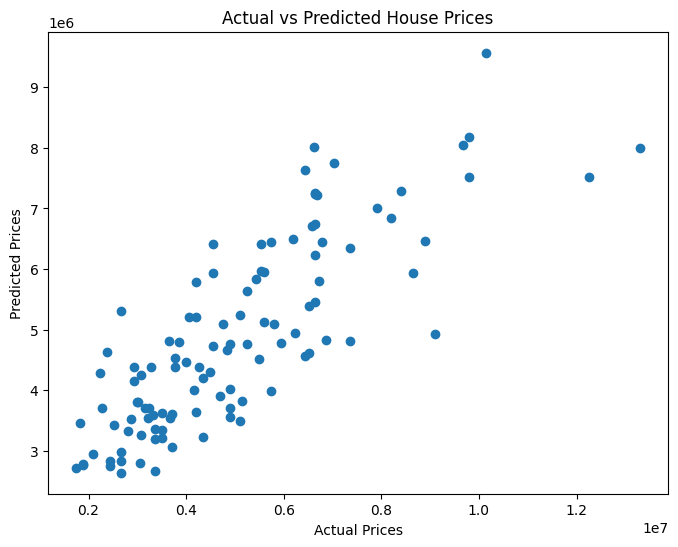

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

# **Feature Importance**

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

             Feature   Coefficient
2          bathrooms  1.097117e+06
8    airconditioning  7.855506e+05
7    hotwaterheating  6.878813e+05
10          prefarea  6.299017e+05
3            stories  4.062232e+05
6           basement  3.931598e+05
4           mainroad  3.668242e+05
5          guestroom  2.331468e+05
9            parking  2.257565e+05
1           bedrooms  7.857449e+04
0               area  2.358488e+02
11  furnishingstatus -2.103971e+05


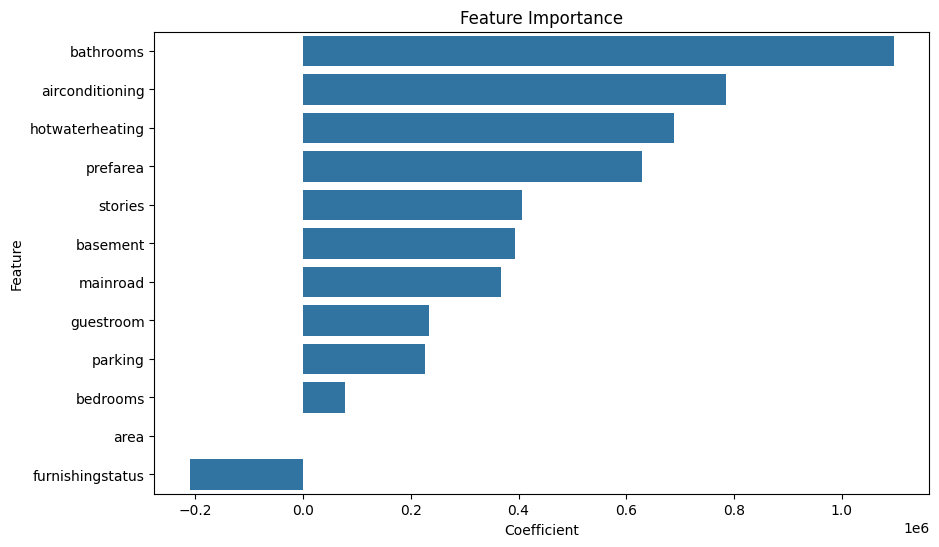

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

# **Conclusion**

A Linear Regression model was developed to predict house prices using property features.

Results:
- Mean Absolute Error (MAE): 979679.6912959901
- Root Mean Squared Error (RMSE): 1331071.4167895108
- R² Score:  0.6494754192267803

Key Findings:
- Area was one of the most influential factors affecting house prices.
- Property facilities such as air conditioning, parking, and furnishing status also contributed to price prediction.
- The model demonstrated good predictive performance for estimating house prices.